# Normalized squared-IEM tilt ($f_{2}$) — $\lambda$ as temperature

Companion to `phase2_pcn_calibration.ipynb`. That notebook tilts with the **expected IEM distance**

$$f_{1}(x) := \mathbb{E}_{x'\sim p}[D_{IEM}(x,x')].$$

Here we present the **normalized expected squared** IEM tilt

$$f_{2}(x) := \frac{\mathbb{E}_{x'\sim p}[D^2_{IEM}(x,x')]}{\mathbb{E}_{x',x''\sim p}[D^2_{IEM}(x',x'')]},$$

and sample from $q_{\lambda}(x)\propto p(x)\exp(\lambda f_{2}(x))$ with the *same* gradient-free SMC / pCN sampler.

Two library pieces make this a drop-in:
- `SquaredGlobalIEMDistance` — returns $D^2_{IEM}$ (the pre-sqrt IEM integral), injectable into any reference selector;
- `RandomRefs(...).normalized_reward(R)` — the $f_{2}$ reduction: expected squared distance divided by the constant denominator $\mathbb{E}_{x',x''\sim p}[D^2_{IEM}]$, estimated by reusing the frozen refs.

Because $f_{2}$ is **normalized** (mean over $p$ is $\approx 1$, unitless), we treat $\lambda$ directly as a **temperature** and sweep it — no $\lambda_{0}$ calibration.

## What transfers from phase2, and what changes

**Reused verbatim (same objects / calibration):**
- the Swiss-Roll-with-a-hole density `p` and its `log_p_Y` marginal,
- the IEM $\gamma$-window (`GAMMA_LO..GAMMA_HI`, 24 points),
- the latent generator `G = density_generator(p, ...)` — it depends only on `p`, not on `f`,
- the pCN sampler knobs calibrated in phase2 (baked into `PCNKernel` defaults: `s0=0.4`, `target_acc=0.3`, `adapt_rate=0.1`, plus `ess_target=0.7`, `n_mcmc=4`),
- the `grid_normalize` ground truth, `plot_field` / `plot_samples`, and the generator-fidelity TV check.

**Changed for $f_{2}$:**
- `GlobalIEMDistance` → **`SquaredGlobalIEMDistance`** (yields $D^2_{IEM}$),
- `.reward(R)` → **`.normalized_reward(R)`** (the $f_{2}$ reduction),
- **no $\lambda_{0}$** — $\lambda$ is set directly as a temperature and swept.

**Recalibrated / to watch — the usable $\lambda$ range.** $f_{2}$ is a *squared* distance, so off-manifold it grows about as fast as $\log p$ decays. Above a ceiling $\lambda$ the tilt overpowers $p$'s Gaussian tail and $q_{\lambda}$ stops being normalizable — on a finite grid this shows up as mass piling on the boundary (here it collapses around $\lambda\approx 1.5$–$2$). So $f_{2}$'s temperatures are small ($\lambda\lesssim 1$), and we bump the tempering a little (`ess_target=0.9`, `n_mcmc=6`) for the stronger tilts.

In [1]:
import sys, math, time
sys.path.insert(0, '.')                    # notebook lives in the repo root's notebooks/; keep parity with phase2
import torch
from sklearn.datasets import make_swiss_roll
from sklearn.mixture import GaussianMixture
from creativity_measure import (
    Density, SquaredGlobalIEMDistance,
    grid_normalize, make_grid, density_generator, PCNKernel, smc_sample,
)
from creativity_measure.refset import RandomRefs

dtype = torch.float64
torch.set_default_dtype(dtype)

# --- Swiss Roll with a hole: the SAME 2D dataset as phase2 (reused verbatim) ---
DDIM = 2
_X, _t = make_swiss_roll(n_samples=5000, noise=0.0, random_state=42)
_X2d = _X[:, [0, 2]]
_keep = ~((_t >= 8.5) & (_t <= 9.5))                          # remove a wrap -> the "hole"
_gmm = GaussianMixture(n_components=24, covariance_type='spherical', random_state=42).fit(_X2d[_keep])
MEANS = torch.tensor(_gmm.means_, dtype=dtype)
VARS = torch.tensor(_gmm.covariances_, dtype=dtype)
LOGW = torch.log(torch.tensor(_gmm.weights_, dtype=dtype))

def log_pX(x):
    diff = x.unsqueeze(-2) - MEANS; quad = diff.pow(2).sum(-1) / VARS
    return torch.logsumexp(-0.5 * quad - 0.5 * DDIM * torch.log(2 * math.pi * VARS) + LOGW, dim=-1)

def log_pY(y, gamma):
    gamma = torch.as_tensor(gamma, dtype=y.dtype, device=y.device); var = gamma ** 2 * VARS + gamma
    diff = y.unsqueeze(-2) - gamma * MEANS; quad = diff.pow(2).sum(-1) / var
    return torch.logsumexp(-0.5 * quad - 0.5 * DDIM * torch.log(2 * math.pi * var) + LOGW, dim=-1)

def roll_sample(n, generator=None):
    idx = torch.multinomial(torch.exp(LOGW), n, replacement=True, generator=generator)
    return MEANS[idx] + torch.sqrt(VARS[idx]).unsqueeze(-1) * torch.randn(n, 2, dtype=dtype, generator=generator)

p = Density(log_pX, log_pY, sample_fn=roll_sample, d=2)

# --- CHANGED vs phase2: squared IEM distance + normalized reward; NO lambda_0 ---
S = torch.sqrt(VARS).mean().item(); C = 0.75
GAMMA_LO = 1.0 / (C * S) ** 2; GAMMA_HI = 2.0 ** 10
GAMMAS = torch.logspace(math.log2(GAMMA_LO), math.log2(GAMMA_HI), 24, base=2, dtype=dtype)
D2 = SquaredGlobalIEMDistance(p, GAMMAS, num_eps=4, seed=123)          # D_IEM^2   (was GlobalIEMDistance)
reward = RandomRefs(p, distance=D2, seed=0).normalized_reward(16)      # f2 = E[D^2] / E_pair[D^2]  (was .reward)
REFS = reward.x_refs
G = density_generator(p, sigma_min=2e-3, sigma_max=150.0, n_steps=48)  # reused verbatim (depends only on p)

# grid + the lambda-INDEPENDENT tilt field f2 (compute once, reuse for every lambda)
GP, XX, YY, CELL = make_grid((-15, 15), (-15, 15), grid_n=50, dtype=dtype)
LOG_P = p.log_p_X(GP)
F2_GRID = reward(GP)

def hist_pmf(s, gn=50, lo=-15.0, hi=15.0):
    ci = (((s[:, 0] - lo) / (hi - lo)) * (gn - 1)).round().long().clamp(0, gn - 1)
    ri = (((s[:, 1] - lo) / (hi - lo)) * (gn - 1)).round().long().clamp(0, gn - 1)
    k = ri * gn + ci; c = torch.zeros(gn * gn, dtype=dtype); c.scatter_add_(0, k, torch.ones(s.shape[0], dtype=dtype))
    return c / c.sum()

# boundary mask: mass here == the tilt has overpowered p's tail (the normalizability ceiling)
GN = 50
_b = torch.zeros(GN, GN, dtype=torch.bool); _b[0, :] = _b[-1, :] = _b[:, 0] = _b[:, -1] = True
BOUNDARY = _b.reshape(-1)

# generator fidelity (same check as phase2): pCN needs G(N(0, I)) ~ p
_z = torch.randn(3000, 2, generator=torch.Generator().manual_seed(0), dtype=dtype)
TV_G = 0.5 * float((hist_pmf(G(_z)) - hist_pmf(p.sample(3000))).abs().sum())
print(f"K={MEANS.shape[0]} comps  S={S:.2f}  denom C = E_pair[D^2] = {reward._denom:.3f}")
print(f"f2 on grid: median={F2_GRID.median():.2f}  max={F2_GRID.max():.1f}   log p: [{LOG_P.min():.0f}, {LOG_P.max():.0f}]")
print(f"generator fidelity TV(G(z), p.sample) = {TV_G:.3f}   (reused from phase2)")

/usr/local/Caskroom/miniconda/base/envs/creativity-measure/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


K=24 comps  S=0.68  denom C = E_pair[D^2] = 1.343
f2 on grid: median=6.10  max=180.4   log p: [-250, -3]
generator fidelity TV(G(z), p.sample) = 0.255   (reused from phase2)


## The tilt field and its normalizability ceiling

`log p`, the squared-IEM tilt `f2`, and one tilted target `q` at $\lambda = 0.5$. Note how much sharper `f2` climbs off-manifold than the linear tilt in phase2 — that steep growth is exactly what caps the usable temperature.

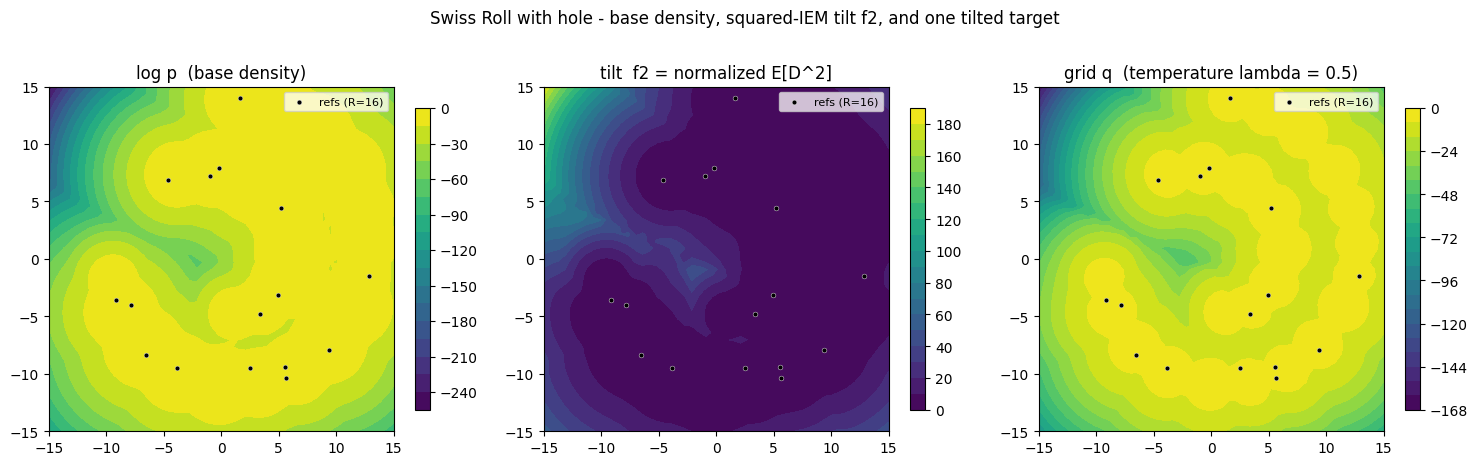

In [2]:
import matplotlib.pyplot as plt
from creativity_measure import plot_field

LAM_SHOW = 0.5
_, q_show, _ = grid_normalize(LOG_P + LAM_SHOW * F2_GRID, CELL)

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.4))
plot_field(LOG_P, XX, YY, ax=axes[0], title="log p  (base density)", refs=REFS)
plot_field(F2_GRID, XX, YY, ax=axes[1], title="tilt  f2 = normalized E[D^2]", refs=REFS)
plot_field(q_show.clamp_min(1e-300).log(), XX, YY, ax=axes[2],
           title=f"grid q  (temperature lambda = {LAM_SHOW})", refs=REFS)
fig.suptitle("Swiss Roll with hole - base density, squared-IEM tilt f2, and one tilted target",
             fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

## Picking interesting $\lambda$ — a fast, SMC-free scan

`grid_normalize` is instant, so we can sweep many temperatures on the grid (reusing the already-computed `F2_GRID`, **no new IEM evals**) and measure how far $q_{\lambda}$ has moved from $p$:

- **`TV(q, p)`** — total variation between $q_{\lambda}$ and $p$ on the grid. $\approx 0$ means "still looks like $p$"; $\to 1$ means fully departed. This is the quantity to watch (that is why $\lambda=0.5$ looked like `log p`: its TV is only $0.12$).
- **`E_q[f2]`** — tilt strength (recall $\mathbb{E}_{p}[f_{2}]=1$, so values $\gg 1$ mean a strong pull off-manifold).
- **`boundary`** — collapse flag.

Pick a $\lambda$ where `TV` is meaningfully non-zero (say $0.3$–$0.9$) while `boundary` is still small.

In [3]:
# SMC-FREE lambda scan (grid only): reuses LOG_P, F2_GRID, CELL, BOUNDARY from the setup cell.
P_PMF = torch.softmax(LOG_P, 0)                       # p as a grid PMF, for TV(q_lambda, p)
print(" lambda   TV(q,p)   E_q[f2]   boundary   note")
for lam in [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]:
    _, q, _ = grid_normalize(LOG_P + lam * F2_GRID, CELL)
    qpmf = q.reshape(-1) / q.reshape(-1).sum()
    tv = 0.5 * float((qpmf - P_PMF).abs().sum())
    ef = float((qpmf * F2_GRID).sum())
    bm = float(qpmf[BOUNDARY].sum())
    note = "~ p (flat)" if tv < 0.15 else ("collapse" if bm > 0.20 else "interesting")
    print(f" {lam:5.2f}    {tv:5.2f}    {ef:7.2f}    {bm:6.1%}    {note}")

 lambda   TV(q,p)   E_q[f2]   boundary   note
  0.00     0.00       1.06      0.3%    ~ p (flat)
  0.25     0.06       1.16      0.3%    ~ p (flat)
  0.50     0.12       1.33      0.4%    ~ p (flat)
  0.75     0.22       1.74      0.5%    interesting
  1.00     0.49       8.11      0.7%    interesting
  1.25     1.00      66.11      0.0%    interesting
  1.50     1.00      71.16      0.0%    interesting
  1.75     1.00     179.83    100.0%    collapse
  2.00     1.00     180.33    100.0%    collapse


## $\lambda$ as temperature — sweep

Each panel shows the grid-truth $\log q_{\lambda}$ (contours) with SMC samples overlaid (white), for increasing temperature $\lambda$. As $\lambda$ rises the **grid** target concentrates in the high-$f_{2}$ region (off-manifold / the hole); the SMC cloud, confined to the manifold, follows only as far as it can.

- **`% of grid`** = SMC $\mathbb{E}[f_{2}]$ vs the grid-truth $\mathbb{E}_{q}[f_{2}]$. It stays near 100% at low temperature and drops as the grid target moves off-manifold, where the pCN proposal (anchored to $p$) cannot follow — the same convergence diagnostic phase2 reports. *Fair only while* `boundary_mass` $\approx 0$; once the grid target collapses to the boundary its denominator is an artifact (see the stronger-$\lambda$ takeaway below for why SMC is right not to follow).
- **`boundary_mass`** = grid-$q$ mass on the domain edge. Non-trivial values flag the normalizability ceiling of the *grid* target (the tilt overpowering $p$'s tail) — a limit SMC itself does not share.

lambda=0.75  grid E_q[f2]=  1.74  boundary_mass= 0.5%  |  SMC E[f2]= 1.61 ( 92% of grid)  levels= 3  uniq=783/800   15s


lambda=1.00  grid E_q[f2]=  8.11  boundary_mass= 0.7%  |  SMC E[f2]= 2.38 ( 29% of grid)  levels= 4  uniq=693/800   20s


lambda=1.25  grid E_q[f2]= 66.11  boundary_mass= 0.0%  |  SMC E[f2]= 4.07 (  6% of grid)  levels= 6  uniq=521/800   30s


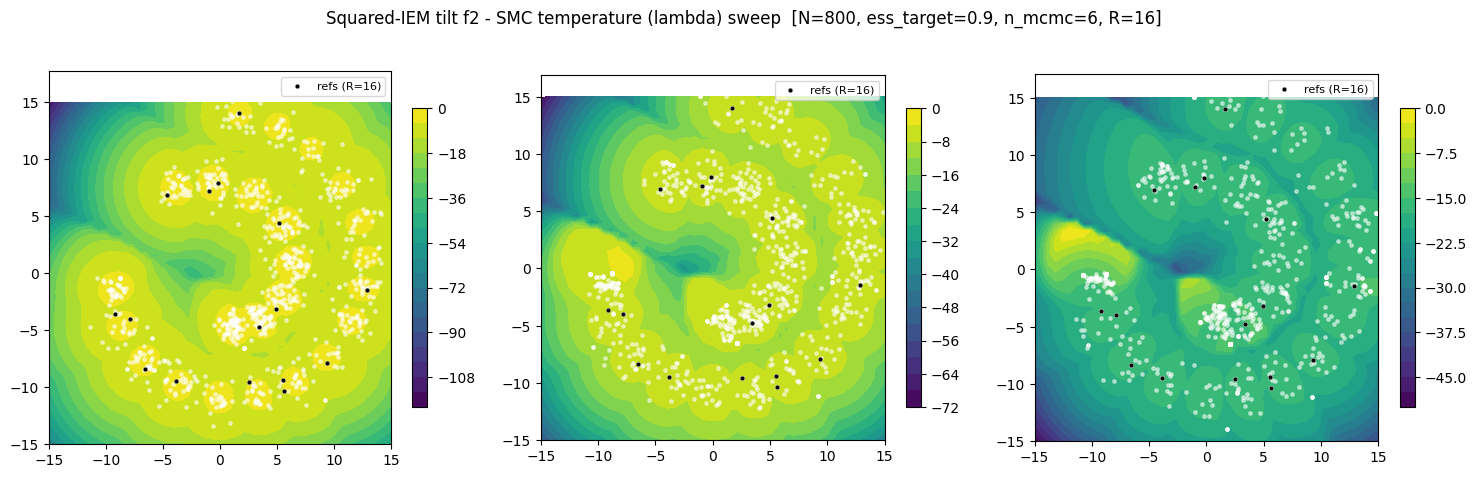

In [4]:
import matplotlib.pyplot as plt
from creativity_measure import plot_field, plot_samples

# lambda is a free TEMPERATURE here (no lambda_0). Values chosen from the SMC-free scan above:
# the interesting band where q_lambda departs from p but has not yet collapsed to the boundary.
LAMBDAS = [0.75, 1.0, 1.25]
N_VIS = 800

fig, axes = plt.subplots(1, len(LAMBDAS), figsize=(5.0 * len(LAMBDAS), 4.4))
for ax, lam in zip(axes, LAMBDAS):
    t = time.time()
    log_q, q, _ = grid_normalize(LOG_P + lam * F2_GRID, CELL)
    qpmf = q.reshape(-1) / q.reshape(-1).sum()
    ef_grid = float((qpmf * F2_GRID).sum())
    bmass = float(qpmf[BOUNDARY].sum())
    res = smc_sample(reward, lam=lam, n_particles=N_VIS,
                     kernel=PCNKernel(G, DDIM), n_mcmc=6, ess_target=0.9,
                     final_resample=True, seed=0)
    ef = float(reward(res.X).mean()); uniq = int(res.X.unique(dim=0).shape[0])
    print(f"lambda={lam:4.2f}  grid E_q[f2]={ef_grid:6.2f}  boundary_mass={bmass:5.1%}  |  "
          f"SMC E[f2]={ef:5.2f} ({ef / ef_grid:4.0%} of grid)  levels={len(res.betas):2d}  "
          f"uniq={uniq}/{N_VIS}  {time.time() - t:3.0f}s")
    plot_field(log_q, XX, YY, ax=ax,
               title=f"lambda = {lam}   (SMC {ef / ef_grid:.0%} of grid)", refs=REFS)
    plot_samples(res.X, ax=ax, alpha=0.5, s=6, color='white')
fig.suptitle(
    f"Squared-IEM tilt f2 - SMC temperature (lambda) sweep  "
    f"[N={N_VIS}, ess_target=0.9, n_mcmc=6, R={REFS.shape[0]}]",
    fontsize=12, y=1.03,
)
plt.tight_layout()
plt.show()

## Does more sampler effort rescue the hard target? ($\lambda = 1.25$)

At $\lambda = 1.25$ the grid target is fully off-manifold and SMC reached only $\approx 6\%$ of grid. Here we **hold $\lambda = 1.25$ fixed** and pump the two convergence knobs in a 3×3:

- **rows** — `ess_target` $\in \{0.90, 0.95, 0.98\}$ (finer tempering schedule; high values only),
- **cols** — `n_mcmc` $\in \{6, 12, 18\}$ (more pCN rejuvenation moves per level).

The grid-$q$ contours are identical in every panel (same $\lambda$); only the white SMC cloud moves. If sampler effort were the bottleneck, the cloud would climb toward the high-$f_{2}$ contours as we go down / right. (Heavy cell — 9 SMC runs at the hardest $\lambda$.)

lambda=1.25: grid E_q[f2]=66.11


  ess_target=0.90  n_mcmc= 6 -> E[f2]= 2.67 (  4% of grid)  levels= 5  uniq=245/300    15s


  ess_target=0.90  n_mcmc=12 -> E[f2]= 3.16 (  5% of grid)  levels= 6  uniq=242/300    33s


  ess_target=0.90  n_mcmc=18 -> E[f2]= 3.96 (  6% of grid)  levels= 6  uniq=196/300    49s


  ess_target=0.95  n_mcmc= 6 -> E[f2]= 2.63 (  4% of grid)  levels= 6  uniq=248/300    19s


  ess_target=0.95  n_mcmc=12 -> E[f2]= 5.18 (  8% of grid)  levels=10  uniq=154/300    57s


  ess_target=0.95  n_mcmc=18 -> E[f2]= 4.13 (  6% of grid)  levels= 9  uniq=208/300    75s


  ess_target=0.98  n_mcmc= 6 -> E[f2]= 2.68 (  4% of grid)  levels=10  uniq=259/300    26s


  ess_target=0.98  n_mcmc=12 -> E[f2]= 3.75 (  6% of grid)  levels=13  uniq=224/300    67s


  ess_target=0.98  n_mcmc=18 -> E[f2]= 3.02 (  5% of grid)  levels=11  uniq=260/300    86s


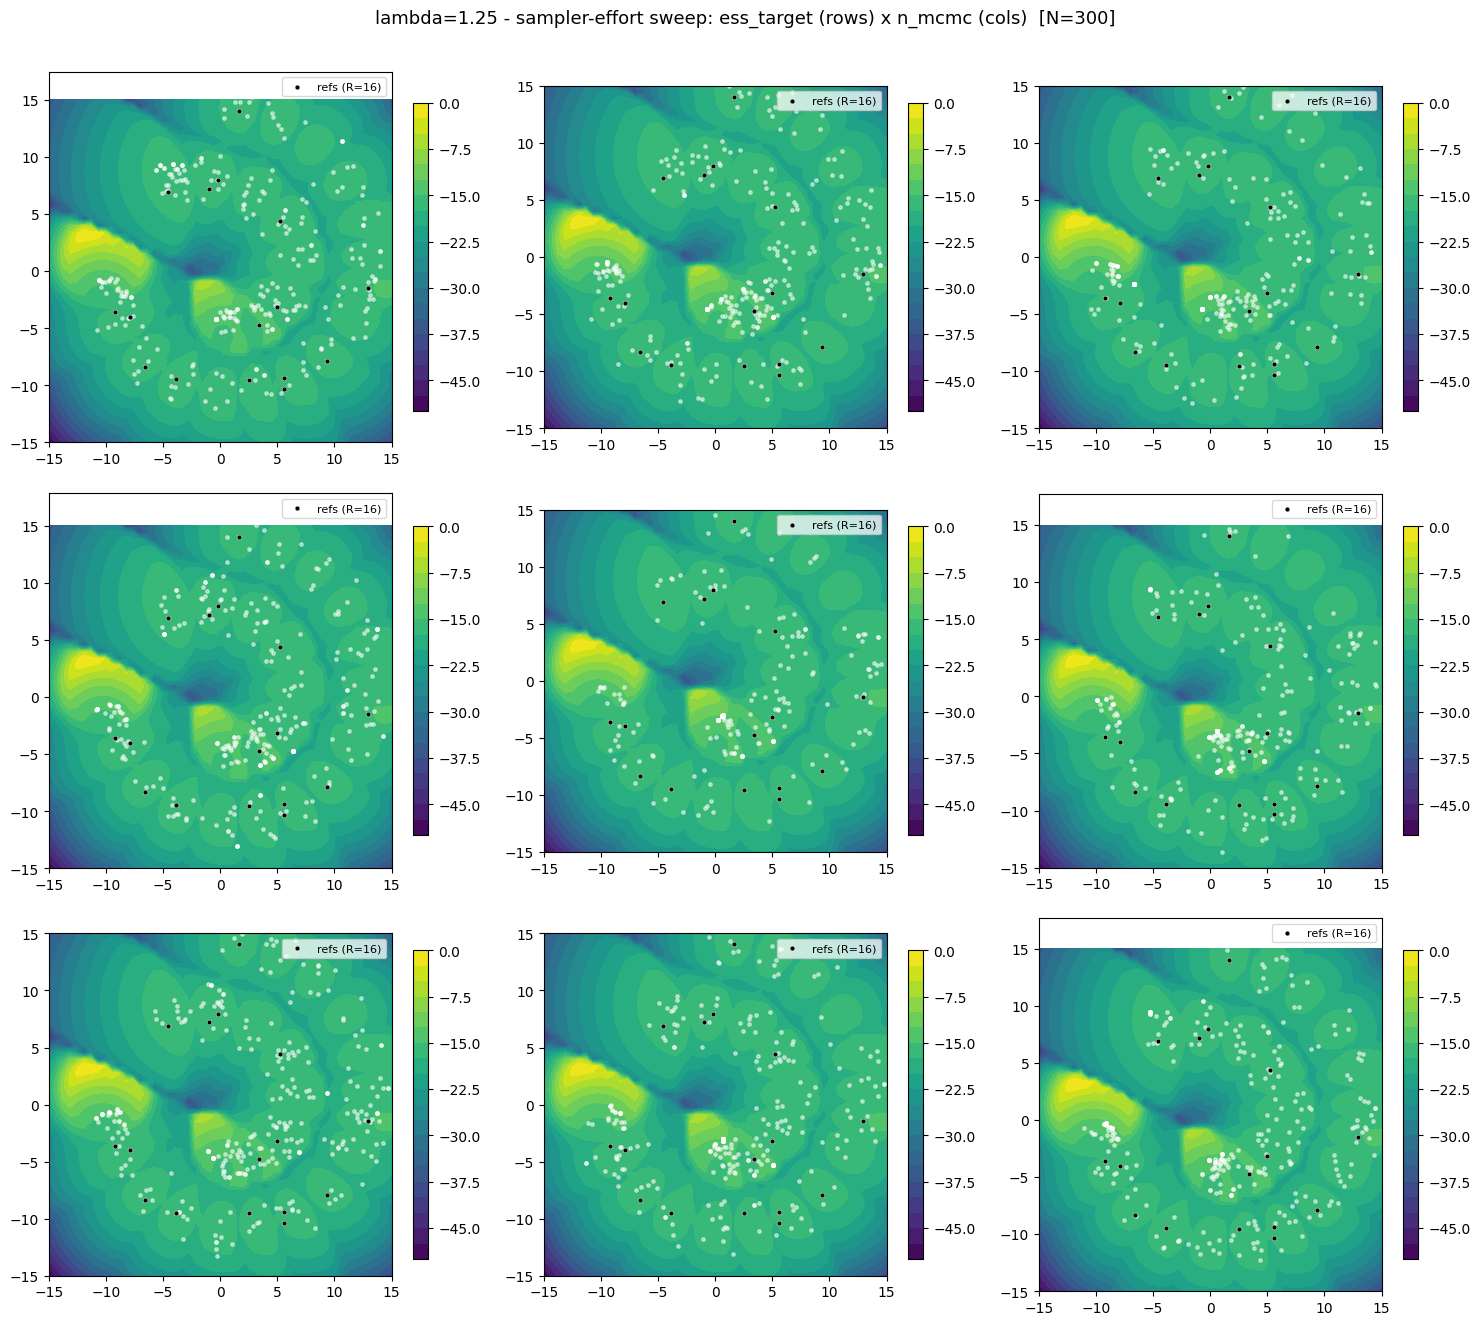

In [5]:
import matplotlib.pyplot as plt
from creativity_measure import plot_field, plot_samples

# Fixed lambda = 1.25 (the hard, strongly-tilted target). 3x3 = ess_target (rows) x n_mcmc (cols).
# Grid-q truth is identical in every panel; only the white SMC cloud changes.
LAM_HARD = 1.25
N_HARD = 300
ESS_TARGETS = [0.90, 0.95, 0.98]     # rows (high values only)
N_MCMCS = [6, 12, 18]                # cols

log_q_hard, q_hard, _ = grid_normalize(LOG_P + LAM_HARD * F2_GRID, CELL)
EF_GRID_HARD = float((q_hard.reshape(-1) / q_hard.reshape(-1).sum() * F2_GRID).sum())
print(f"lambda={LAM_HARD}: grid E_q[f2]={EF_GRID_HARD:.2f}")

fig, axes = plt.subplots(len(ESS_TARGETS), len(N_MCMCS),
                         figsize=(5.0 * len(N_MCMCS), 4.4 * len(ESS_TARGETS)))
for i, ess in enumerate(ESS_TARGETS):
    for j, nm in enumerate(N_MCMCS):
        ax = axes[i, j]; t = time.time()
        res = smc_sample(reward, lam=LAM_HARD, n_particles=N_HARD,
                         kernel=PCNKernel(G, DDIM), n_mcmc=nm, ess_target=ess,
                         final_resample=True, seed=0)
        ef = float(reward(res.X).mean()); uniq = int(res.X.unique(dim=0).shape[0])
        pct = ef / EF_GRID_HARD
        print(f"  ess_target={ess:.2f}  n_mcmc={nm:2d} -> E[f2]={ef:5.2f} ({pct:4.0%} of grid)  "
              f"levels={len(res.betas):2d}  uniq={uniq}/{N_HARD}  {time.time() - t:4.0f}s")
        plot_field(log_q_hard, XX, YY, ax=ax,
                   title=f"ess={ess}, n_mcmc={nm}  ({pct:.0%} of grid)", refs=REFS)
        plot_samples(res.X, ax=ax, alpha=0.5, s=6, color='white')
fig.suptitle(
    f"lambda={LAM_HARD} - sampler-effort sweep: ess_target (rows) x n_mcmc (cols)  [N={N_HARD}]",
    fontsize=13, y=1.005,
)
plt.tight_layout()
plt.show()

### What the effort sweep shows

Coverage stays pinned at **4–8% of grid** across the whole 3×3 — more effort does not rescue $\lambda = 1.25$:

- **`n_mcmc` helps a little.** More rejuvenation moves let particles drift up the $f_{2}$ gradient (at `ess_target=0.90`, `E[f2]` climbs $2.67 \to 3.16 \to 3.96$ as `n_mcmc` $6 \to 12 \to 18$), so a few more samples reach the high-mass region — but the cloud stalls near $p$ and never crosses to the off-manifold mode.
- **`ess_target` does not** (and higher values look *more* like $p$). A finer schedule adds tempering levels ($5 \to 13$), but with a proposal anchored to $p$ each extra level mostly re-equilibrates particles back toward $p$'s bulk between the tiny $\beta$-steps. Going the *other* way — very small `ess_target` — only fakes coverage through weight degeneracy (few unique particles: e.g. the 8% cell had `uniq`=154/300 vs 242 at `ess=0.90`), so keep it in the reliable $0.7$–$0.9$ range.

**The ceiling is the proposal, not the effort.** Both kernels are anchored to $p$'s support (`IndependenceKernel` draws $x'\sim p$; `PCNKernel` moves in the latent mapping $N(0,I)\to p$), while the $\lambda = 1.25$ grid mode lives *outside* that support. Reaching that off-manifold mode would need a wider-dispersion proposal (a new kernel), not more `n_mcmc` or `ess_target` — though, as the stronger-$\lambda$ sweep shows next, SMC's confinement to the manifold is actually the behavior we want.

## Into the collapse regime (grid only) — a stronger-$\lambda$ sweep

Nine increasing temperatures $\lambda \in \{1.25, 1.5, \dots, 3.25\}$ (step $0.25$), using the **best effort config** from the 3×3 above — `ess_target=0.90` (cleanest, least $p$-like) and `n_mcmc=18` (pushed furthest toward the mode). From the earlier scan, $\lambda \gtrsim 1.75$ is the **grid** collapse regime: the *finite-grid* $q$ becomes non-normalizable and its mass piles on the domain boundary (an artifact of enumerating off-manifold points). The sweep is built to show the contrast — the grid-$q$ contours degenerate toward the corners, while the SMC cloud **cannot escape the manifold** and instead converges toward the high-$f_{2}$ manifold regions. The takeaway right under the plot unpacks why.

lambda=1.25  grid E_q[f2]=  66.11  boundary= 0.0%  |  SMC E[f2]= 3.96 (  6% of grid)  levels= 6  uniq=196/300    53s


lambda=1.50  grid E_q[f2]=  71.16  boundary= 0.0%  |  SMC E[f2]= 5.56 (  8% of grid)  levels= 8  uniq=130/300    75s


lambda=1.75  grid E_q[f2]= 179.83  boundary=100.0%  |  SMC E[f2]= 6.61 (  4% of grid)  levels= 9  uniq=74/300    83s


lambda=2.00  grid E_q[f2]= 180.33  boundary=100.0%  |  SMC E[f2]= 7.13 (  4% of grid)  levels=10  uniq=46/300    94s


lambda=2.25  grid E_q[f2]= 180.38  boundary=100.0%  |  SMC E[f2]= 7.60 (  4% of grid)  levels=11  uniq=48/300   104s


lambda=2.50  grid E_q[f2]= 180.38  boundary=100.0%  |  SMC E[f2]= 9.60 (  5% of grid)  levels=14  uniq=112/300   131s


lambda=2.75  grid E_q[f2]= 180.39  boundary=100.0%  |  SMC E[f2]=21.18 ( 12% of grid)  levels=19  uniq=176/300   177s


lambda=3.00  grid E_q[f2]= 180.39  boundary=100.0%  |  SMC E[f2]=26.77 ( 15% of grid)  levels=22  uniq=155/300   206s


lambda=3.25  grid E_q[f2]= 180.39  boundary=100.0%  |  SMC E[f2]=28.44 ( 16% of grid)  levels=23  uniq=134/300   218s


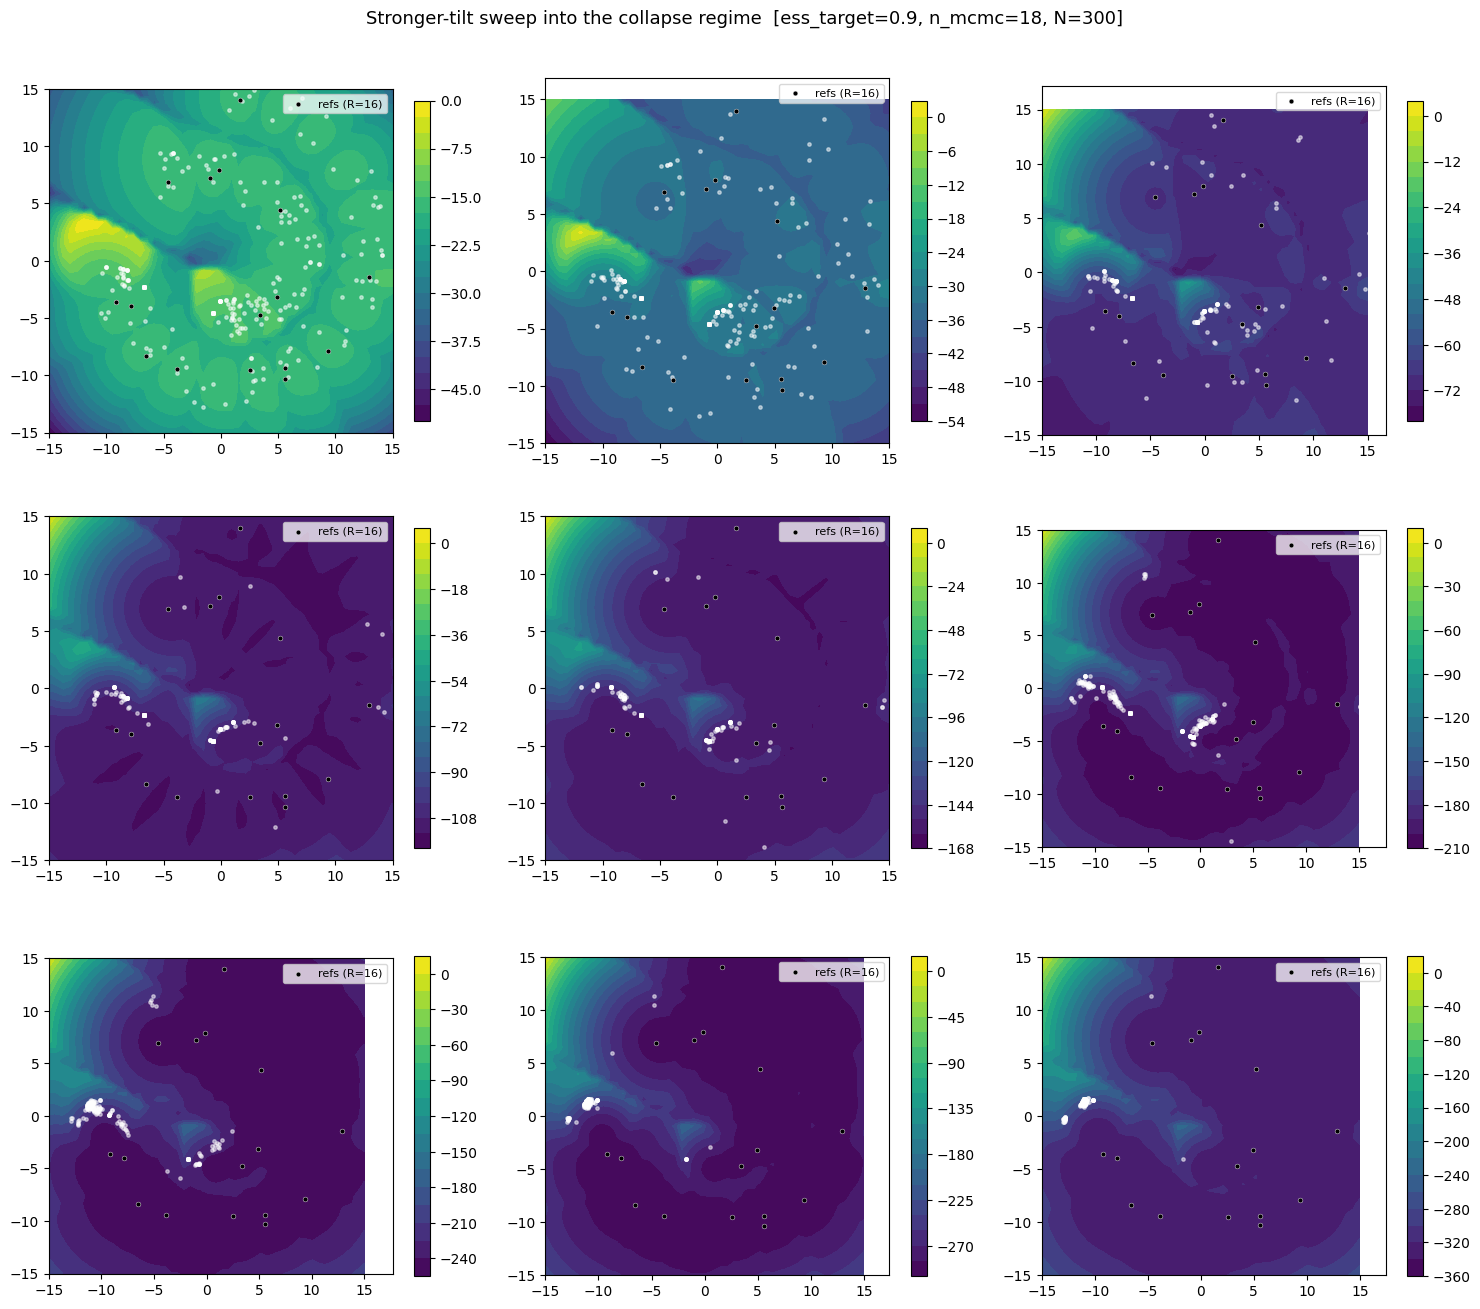

In [6]:
import matplotlib.pyplot as plt
from creativity_measure import plot_field, plot_samples

# Best effort config from the 3x3 above (ess=0.90 looked cleanest; n_mcmc=18 pushed furthest).
ESS_BEST, NMCMC_BEST = 0.90, 18
N_STRONG = 300
STRONG_LAMBDAS = [1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25]   # 9 values -> 3x3, increasing

fig, axes = plt.subplots(3, 3, figsize=(15.0, 13.2))
for ax, lam in zip(axes.ravel(), STRONG_LAMBDAS):
    t = time.time()
    log_q, q, _ = grid_normalize(LOG_P + lam * F2_GRID, CELL)
    qpmf = q.reshape(-1) / q.reshape(-1).sum()
    ef_grid = float((qpmf * F2_GRID).sum()); bmass = float(qpmf[BOUNDARY].sum())
    res = smc_sample(reward, lam=lam, n_particles=N_STRONG,
                     kernel=PCNKernel(G, DDIM), n_mcmc=NMCMC_BEST, ess_target=ESS_BEST,
                     final_resample=True, seed=0)
    ef = float(reward(res.X).mean()); uniq = int(res.X.unique(dim=0).shape[0])
    print(f"lambda={lam:4.2f}  grid E_q[f2]={ef_grid:7.2f}  boundary={bmass:5.1%}  |  "
          f"SMC E[f2]={ef:5.2f} ({ef / ef_grid:4.0%} of grid)  levels={len(res.betas):2d}  "
          f"uniq={uniq}/{N_STRONG}  {time.time() - t:4.0f}s")
    tag = "  [collapse]" if bmass > 0.20 else ""
    plot_field(log_q, XX, YY, ax=ax,
               title=f"lambda = {lam}   (SMC {ef / ef_grid:.0%} of grid){tag}", refs=REFS)
    plot_samples(res.X, ax=ax, alpha=0.5, s=6, color='white')
fig.suptitle(
    f"Stronger-tilt sweep into the collapse regime  "
    f"[ess_target={ESS_BEST}, n_mcmc={NMCMC_BEST}, N={N_STRONG}]",
    fontsize=13, y=1.002,
)
plt.tight_layout()
plt.show()

### What the stronger-$\lambda$ sweep shows — SMC does not escape

The grid and SMC panels tell **different stories on purpose**, and that difference is the point:

- **Mass cannot escape in SMC.** Every particle is $x = G(z)$: the pCN kernel proposes a *latent* $z'$ and maps it through the generator $G$, and resampling only reselects existing particle locations. So the particle support is always $\subseteq \mathrm{Image}(G) \approx \mathrm{supp}\,p$ (the data manifold). No step can place a particle in the off-manifold void where the grid dumps its mass — the tilt only **reweights within the manifold**.
- **So the grid "collapse" is grid-only.** The grid enumerates the whole box, including off-manifold points where $f_{2}\approx 180$; $\exp(\lambda f_{2})$ sends all its mass to the corner. On the *reachable* manifold $f_{2}$ is bounded, so the tilt restricted there is a **proper distribution for every $\lambda$** — SMC stays well-posed exactly where the literal $q_{\lambda}\propto p\exp(\lambda f_{2})$ over $\mathbb{R}^2$ does not.
- **SMC converges to the right places, just slower.** Instead of escaping, the white cloud concentrates on the highest-$f_{2}$ *reachable* points — the manifold edges / hole boundary that the valid $\lambda\approx 1.25$ tilt already highlighted — drifting further out as $\lambda$ grows ($\mathbb{E}[f_{2}]$ crept $4 \to 28$ over $\lambda = 1.25 \to 3.25$, never near the corner's $180$). The grid reweights globally and instantly; SMC must *transport* particles along the manifold with local pCN moves, so it lags.
- **Hence `% of grid` is the wrong yardstick past $\lambda\approx 1.5$** (`boundary_mass` $\to 100\%$): its denominator is the boundary artifact, not a real target. For strong $\lambda$ read the $\mathbb{E}[f_{2}]$ trend, `uniq` / `ess_history`, and the visual convergence to high-novelty manifold regions instead.

This is the *desirable* behavior for the creativity goal: SMC returns creative-but-valid on-manifold samples and is robust to the tilt's formal non-normalizability. Here the grid is the misleading one, not SMC.

## Takeaways

- **$f_{2}$ is a drop-in.** `SquaredGlobalIEMDistance` + `.normalized_reward(R)`, sampled by the same SMC / pCN stack — every other object from phase2 is reused as-is.
- **$\lambda$ is a temperature**, not $m\cdot\lambda_{0}$. $f_{2}$ is unitless (mean $\approx 1$ under $p$), so $\lambda$ is directly interpretable and comparable across densities.
- **The grid target has a normalizability ceiling; SMC does not.** The *literal* $q_{\lambda}\propto p\exp(\lambda f_{2})$ over $\mathbb{R}^2$ (and its grid enumeration) diverges once the squared reward out-grows $\log p$'s decay (here $\lambda\gtrsim 1.5$: `boundary_mass` $\to$ 1). SMC never sees this — its particles are $x = G(z)$, confined to the generator manifold where $f_{2}$ is bounded, so its tilted target stays a **proper distribution for every $\lambda$**.
- **SMC can't escape — it reweights within the manifold.** As $\lambda$ grows the cloud converges to high-novelty on-manifold regions (manifold edges / the hole), *slower* than the grid because pCN transports particles locally rather than reweighting globally. This is the desirable behavior for the creativity goal, and it makes `% of grid` an unfair metric once `boundary_mass` $> 0$ — use the $\mathbb{E}[f_{2}]$ trend / `uniq` / visual convergence there instead.
- **Effort is not the lever at strong $\lambda$.** More `n_mcmc` helps a little (local drift up $f_{2}$); higher `ess_target` does not (and looks more like $p$); very small `ess_target` fakes coverage via weight degeneracy. Keep `ess_target` in the reliable $0.7$–$0.9$ range.

*Note:* the constant denominator $\mathbb{E}_{x',x''\sim p}[D^2_{IEM}]$ makes $f_{2}$ unitless but **cancels** if you ever re-introduce the $\lambda_{0}=\mathrm{std}(\log p)/\mathrm{std}(f)$ calibration — there it only rescales $\lambda$. It matters precisely because we set $\lambda$ by hand here.